<a href="https://colab.research.google.com/github/EsserMishelle/credit-card-fraud-detection/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection
## Project Description

This project develops a machine learning model to detect fraudulent financial transactions using a large-scale transaction dataset from Kaggle. The dataset contains millions of simulated financial transactions labeled as either fraudulent or legitimate.

Exploratory data analysis is performed to understand transaction behavior and identify patterns associated with fraud. Several behavioral and balance-consistency features are engineered to capture suspicious transaction activity.

A logistic regression model is then trained to predict whether a transaction is fraudulent based on transaction characteristics and engineered behavioral features.

-----------------
## Dataset Description

The dataset used in this project is the **PaySim synthetic financial transaction dataset** available on Kaggle. The dataset simulates mobile money transactions and includes labeled fraudulent activities.

- Observations: approximately **6.36 million transactions**
- Fraud cases: **8,213 transactions (0.13%)**
- Features include transaction type, transaction amount, account balances before and after the transaction, and fraud labels.

The dataset is highly imbalanced, with fraudulent transactions representing a very small proportion of the total observations.

-------------------

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Define the folder path
folder_path = '/content/drive/MyDrive/credit-card-fraud-detection/'
os.makedirs(folder_path, exist_ok=True)

# Define the assets folder path
assets_folder_path = '/content/drive/MyDrive/credit-card-fraud-detection/assets'
os.makedirs(assets_folder_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load the data
# Reset index to ensure 'step' is treated as a feature column, not an index

fraud_file_path = os.path.join(folder_path, 'fraud.csv')

transactions= pd.read_csv(fraud_file_path, index_col=0 )
transactions= transactions.reset_index()

--------------
## Project Objectives
- Build a machine learning classifier to detect fraudulent transactions
- Evaluate model performance using ROC-AUC and confusion matrix metrics
- Examine model coefficients to understand influential features
- Demonstrate techniques for working with imbalanced datasets

--------
## Exploratory Data Analysis (EDA)

In [4]:
display(transactions.head(20))
print(transactions.info())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None


The dataset has 636K entries, 11 features and no null values.

In [5]:
# Summary statistics on amount column
transactions.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


### Fraud distribution (class imbalance)

In [6]:
fraud_count = transactions['isFraud'].value_counts()
fraud_count_percent = fraud_count / len(transactions) * 100

isFlaggedFraud_count = transactions['isFlaggedFraud'].value_counts()
isFlaggedFraud_percent = isFlaggedFraud_count / len(transactions) * 100

# combine into a pd.DataFrame
fraud_summary = pd.DataFrame({
    'fraudCount': fraud_count,
    'fraud_%': fraud_count_percent,
    'isFlaggedFraudCount': isFlaggedFraud_count,
    'isFlaggedFraud_%': isFlaggedFraud_percent,
    'fraudCapture_%': isFlaggedFraud_count/fraud_count *100
})
fraud_summary = fraud_summary.round(4)
display(fraud_summary)

,fraudCount,fraud_%,isFlaggedFraudCount,isFlaggedFraud_%,fraudCapture_%
0,6354407,99.8709,6362604,99.9997,100.1290
1,8213,0.1291,16,0.0003,0.1948


### Class Distribution

The dataset is highly imbalanced. Fraudulent transactions represent only 0.13% of all observations, while non-fraudulent transactions account for more than 99.8% of the data.

This imbalance presents a challenge for machine learning models because traditional accuracy metrics can be misleading. A model that predicts all transactions as non-fraudulent would still achieve over 99% accuracy.

The dataset also includes a rule-based fraud flag (`isFlaggedFraud`). However, this rule detects only 16 transactions out of more than 8,000 fraudulent cases, indicating that simple threshold-based detection captures only a very small fraction of fraud events.

Therefore, model performance will be evaluated using metrics better suited for imbalanced classification problems, such as ROC-AUC, precision, recall, and confusion matrices.

#### Fraudulent Type Analysis

In [7]:
# These are the transaction types in this dataset
transactions['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [8]:
transactions.groupby('type')['isFraud'].mean()

,isFraud
type,
CASH_IN,0.000000
CASH_OUT,0.001840
DEBIT,0.000000
PAYMENT,0.000000
TRANSFER,0.007688


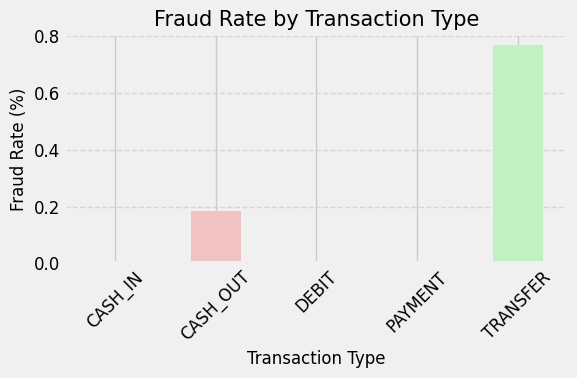

In [33]:
import matplotlib.pyplot as plt

# Calculate fraud rate by transaction type
fraud_by_type = transactions.groupby('type')['isFraud'].mean() * 100

# Create a colorful bar chart
plt.figure(figsize=(6, 4))
colors = ['#ff9999', '#f0c2c2', '#99ff99', '#ffcc99', '#c2f0c2']  # Custom color palette
fraud_by_type.plot(kind='bar', color=colors)

# Add labels and title
plt.ylabel('Fraud Rate (%)', fontsize=12, color='black')
plt.xlabel('Transaction Type', fontsize=12, color='black')
plt.title('Fraud Rate by Transaction Type', fontsize=15, color='black')
plt.xticks(rotation=45, fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

# Show grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the chart
plt.tight_layout()
plt.show()

Fraud rates vary dramatically by transaction type:
- **TRANSFER** transactions have the highest fraud rate (~76.9%)
- **CASH_OUT** transactions show high fraud rate (~18.4%)
- **PAYMENT**, **DEBIT**, and **CASH_IN** transactions show near-zero fraud rates

This pattern indicates that fraudulent activity is concentrated in transactions involving the transfer (`TRANSFER`) or withdrawal (`CASH_OUT`) of funds, rather than routine consumer payment activity.


#### Fraudulent Amount Analysis

/tmp/ipykernel_11600/3771871156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=transactions, x='isFraud', y='amount', palette=['#c2f0c2', '#9999e6'])


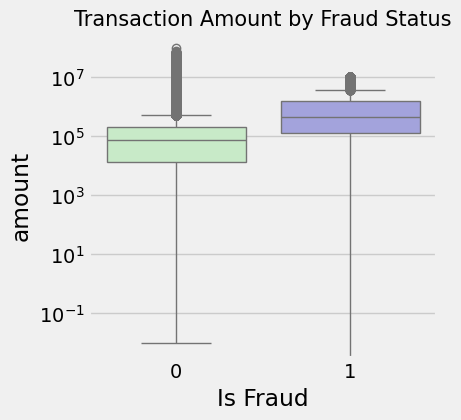

In [45]:
plt.figure(figsize=(4,4))

sns.boxplot(data=transactions, x='isFraud', y='amount', palette=['#c2f0c2', '#9999e6'])
plt.yscale('log')
plt.xlabel('Is Fraud')
plt.title('Transaction Amount by Fraud Status', size=15)
plt.show()


A log scale is applied because transaction amounts exhibit a strong right-skewed distribution.

The visualization shows that fraudulent transactions tend to occur more frequently among higher-value transactions compared with non-fraudulent ones. However, large transaction amounts alone do not necessarily imply fraudulent activity.

Therefore, the `amount` feature will be retained as a supporting predictor alongside other engineered behavioral and balance-related features.

### Feature Engineering

To capture the behavioral signal decribed above, transaction types are transformed into interpretable indicators instead of applying one-hot encoding. Two features are engineered:

`isMovement` – flags transactions involving direct fund transfers ('TRANSFER', 'CASH_OUT'), which show substantially higher fraud risk

`isPayment` – flags routine consumer payment activity ('PAYMENT', 'DEBIT'), which exhibits minimal fraud occurrence

These features allow the model to focus on transaction intent and behavioral risk patterns, rather than treating each transaction type as an unrelated category.

In some transactions, the destination balance fields (`oldbalanceDest` and `newbalanceDest`) remain zero even after money is transferred. This indicates that balance information may be missing or not updated in the dataset.

For legitimate transactions, the following accounting relationships are expected:

oldbalanceOrg − amount = newbalanceOrig  
oldbalanceDest + amount = newbalanceDest

When these identities do not hold, inconsistencies occur between the transaction amount and the recorded balances. Balance mismatch features are engineered to flag such inconsistencies.

In [50]:
# The two ususal fraudulent transaction types occurred in this dataset are: 'CASH_OUT' and 'TRANSFER'.
transactions['isMovement'] = transactions['type'].isin(['CASH_OUT', 'TRANSFER']).astype(int)

# The two regular consumer transactions are: 'Payment' and 'DEBIT'.
transactions['isPayment'] = transactions['type'].isin(['PAYMENT', 'DEBIT']).astype(int)

# Transaction `amount` alone does not capture realistic balances update.
# Measure the absolute change in the destination account balance to capture
# unusally large or inconsistent balance updates

transactions['accountDiff'] = (
    transactions['oldbalanceDest'] - transactions['newbalanceDest']
).abs()

# Balance consistency check (fraud if is it non-zero)
transactions['balanceErrorOrig'] = (
    transactions['oldbalanceOrg'] - transactions['amount'] - transactions['newbalanceOrig']
)

# Check balance inconsistency that is not due to rounding tolerance
eps = 1e-6

transactions['origBalanceMismatch'] = (
    abs(transactions['oldbalanceOrg'] - transactions['amount'] - transactions['newbalanceOrig']) > eps
).astype(int)

transactions['destBalanceMismatch'] = (
    abs(transactions['oldbalanceDest'] + transactions['amount'] - transactions['newbalanceDest']) > eps
).astype(int)

transactions['amountRatio'] = transactions['amount'] / transactions['oldbalanceOrg']

### Pearson Correlation

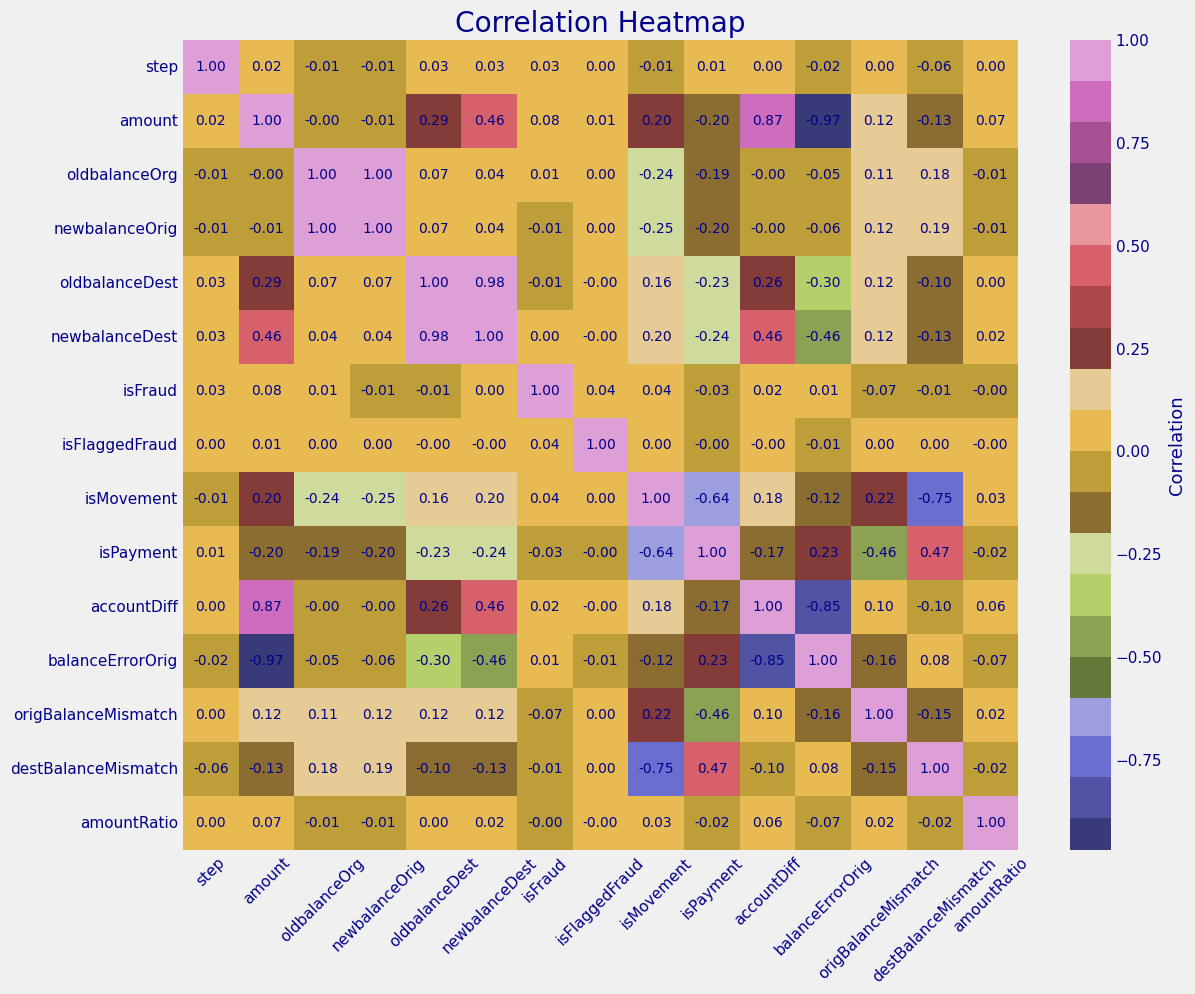

In [80]:
plt.figure(figsize=(12,10))
plt.style.use('fivethirtyeight')

# sns.set_theme(style="darkgrid")
ax=  sns.heatmap(
    transactions.corr(numeric_only=True),
    # cmap="coolwarm",
    # cmap="Accent",
    cmap="tab20b",
    center=0,
    annot=True,
    annot_kws={'fontsize': 10, 'color': 'darkblue'},
    fmt=".2f",
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='darkblue')
cbar.set_label('Correlation', color='darkblue', fontsize=13)

plt.xticks(rotation=45, color='darkblue')
plt.yticks(color='darkblue')
plt.title('Correlation Heatmap', color='darkblue')
plt.show()

In [52]:
# Fraud correlation ranking
transactions.corr(numeric_only= True)['isFraud'].sort_values(ascending = False).round(3)

,isFraud
isFraud,1.000
amount,0.077
isFlaggedFraud,0.044
isMovement,0.041
step,0.032
accountDiff,0.025
balanceErrorOrig,0.011
oldbalanceOrg,0.010
newbalanceDest,0.001
amountRatio,-0.001


#### Observations
- Fraud is most positively correlated with `isMovement` (0.041) and `amount` (0.077).
- Fraud is negatively correlated with `isPayment` (-0.026).
- The `step` feature shows moderate correlation but represents time ordering rather than transaction behavior.

#### Important Considerations
The `step` feature represents the number of hours since the beginning of the dataset rather than a real-world business attribute. Because future steps would not be known at prediction time, including this feature could introduce data leakage. For this reason, `step` is excluded from feature engineering.

In [53]:
# Create features and label variables
features = [
    'amount',
    'isPayment',
    'isMovement',
    'accountDiff',
    'origBalanceMismatch',
    'destBalanceMismatch'
]

label= 'isFraud'

# Split dataset
X = transactions[features]
y = transactions[label]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 42,
    stratify=y)

# Model Training

#### Feature Scaling

In [58]:
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)


#### Model Training

In [63]:
# Train the logistic regression model
lr = LogisticRegression(class_weight='balanced', max_iter=1000)

lr.fit(X_train_ss, y_train)


# Score the model on the training data
train_acc = lr.score(X_train_ss, y_train)

# Score the model on the test data
test_acc = lr.score(X_test_ss, y_test)

print(f'Train accuracy: {train_acc}')
print(f'Test accuracy: {test_acc}')

# Print the model coefficients
print(f'The logistic model\'s coefficients: {lr.coef_}')

Train accuracy: 0.9592822723074097
Test accuracy: 0.9592542066004256
The logistic model's coefficients: [[ 1.43547161 -4.38757089  2.73546882 -1.33176752 -3.01591391  0.51607763]]


Both the train and test accuracy score around 96% with a slight overfitting.

### Model Evaluation & Interpretation
#### Confusion Matrix

,Predicted Not Fraud (0),Predicted Fraud (1)
Actual Not Fraud (0),"1,828,557","77,765"
Actual Fraud (1),10,"2,454"


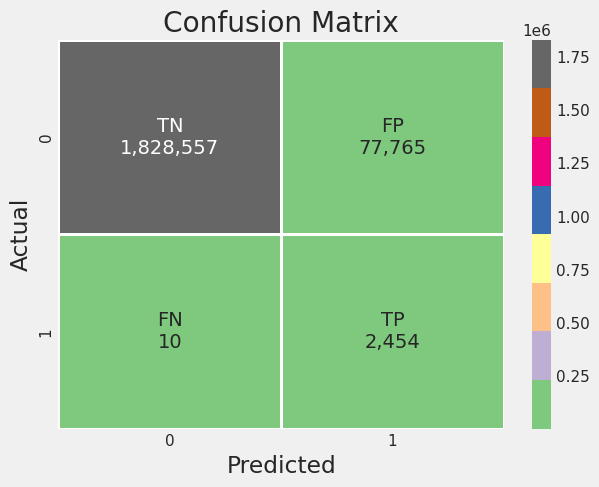

In [93]:
from sklearn.metrics import confusion_matrix

y_pred = lr.predict(X_test_ss)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual Not Fraud (0)', 'Actual Fraud (1)'], columns=['Predicted Not Fraud (0)', 'Predicted Fraud (1)'])

display(cm_df.style.format('{:,}'))
print()
labels = np.array([
    [f'TN\n{cm[0,0]:,}', f'FP\n{cm[0,1]:,}'],
    [f'FN\n{cm[1,0]:,}', f'TP\n{cm[1,1]:,}']
])

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap= 'Accent',
    linewidths=1,
    linecolor='white'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Confusion Matrix Analysis

The confusion matrix summarizes the model’s classification performance on the test dataset.

- **True Negatives (TN)** = 1,828,557  
- **False Positives (FP)** = 77,765  
- **False Negatives (FN)** = 10  
- **True Positives (TP)** = 2,454  

The model detects nearly all fraudulent transactions, missing only 10 cases. This corresponds to a very high recall for the fraud class.

However, the model also flags a substantial number of legitimate transactions as fraudulent (77,765 false positives). This indicates that the model favors identifying potential fraud even at the cost of additional false alerts.

In fraud detection systems, this trade-off is often acceptable because failing to detect fraudulent transactions can be more costly than investigating flagged transactions.

It is also worth noting that the dataset is synthetic. Some engineered rule-based features (such as balance inconsistencies) may make fraudulent behavior easier to detect than in real financial transaction data.



In [94]:
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test_ss)

print('\nClassification Report: ')
print(classification_report(y_test, y_pred))


Classification Report: 
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1906322
           1       0.03      1.00      0.06      2464

    accuracy                           0.96   1908786
   macro avg       0.52      0.98      0.52   1908786
weighted avg       1.00      0.96      0.98   1908786



#### Classification Report Analysis

The classification report provides additional insight into model performance beyond overall accuracy.

The model achieves an overall test accuracy of approximately **96%**. However, accuracy alone is not an informative metric in this case because fraudulent transactions represent only a very small portion of the dataset.

For legitimate transactions (class 0), the model achieves very high precision and recall, correctly identifying the majority of non-fraudulent transactions.

For fraudulent transactions (class 1), the model achieves **very high recall (1.00)**, meaning that nearly all fraudulent transactions are successfully detected. This result is consistent with the confusion matrix, which shows only a small number of missed fraud cases.

However, the **precision for the fraud class is very low (0.03)**. This indicates that many legitimate transactions are incorrectly flagged as fraud, resulting in a large number of false positives.

Because fraud detection datasets are highly imbalanced, metrics such as **recall, precision, F1 score, and ROC-AUC** provide a more meaningful evaluation of model performance than accuracy alone.


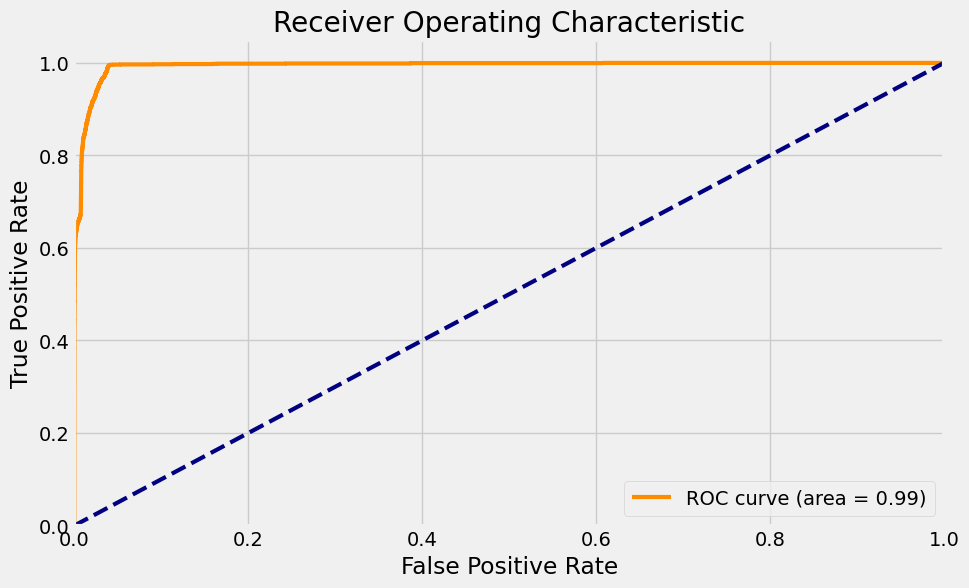

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc

y_pred = lr.predict(X_test_ss)
y_probs =lr.predict_proba(X_test_ss)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.style.use('fivethirtyeight')
plt.plot(fpr, tpr, color='darkorange', lw=3, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# ROC AUC Curve Analysis:
The ROC curve shows how well the model identifies fraudulent transactions while controlling false larms. An AUC of 1.00 indicates the model's near-perfect fraud identifying performance. However, this performance is likely optimistic given the synthetic nature of the data and the inclusion of strong rule-based features (mismatch balances)


---

# Coefficient Bar Chart -
to interpret logistic regression




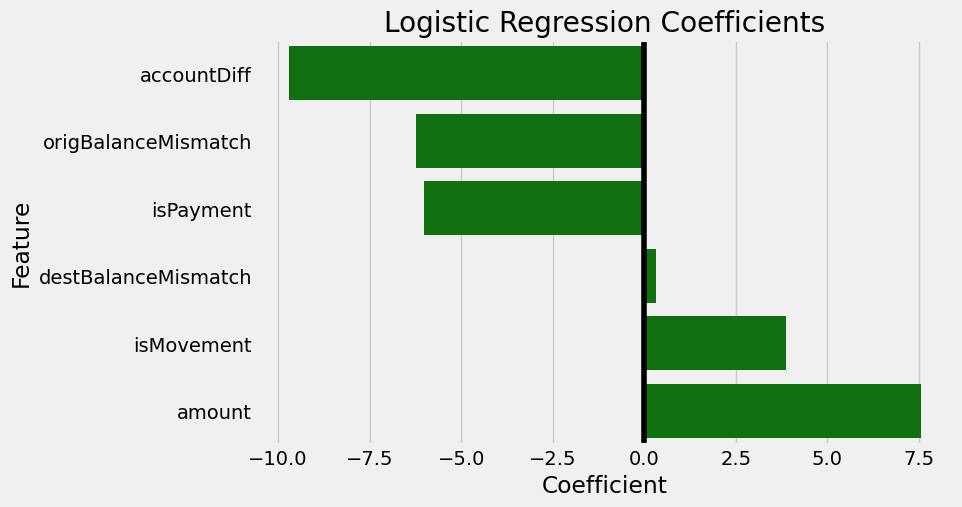

In [21]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient')

plt.figure(figsize=(8,5))
plt.style.use('fivethirtyeight')
sns.barplot(data=coef_df, x='Coefficient', y='Feature', color='green')
plt.title('Logistic Regression Coefficients')
plt.axvline(0, color='black')
plt.show()


## Coefficient Analysis:
* According to the chart, `amount` and `isMovement` have the strongest coefficients, indicating that large amount and money-movements have strong association with fraud.  
* However, `isPayment` and `accountDiff` have negative coefficients, indicating they are associated with a lower probability of fraud.
* The mismatch balance features might have added signal for the model to detect abnormal behavior.

---

# Reduced feature set
The coefficient analysis highlights the `origBalanceMismatch` feature, which the model relies on most strongly. While balance mismatch indicators (`origBalanceMismatch`, `destBalanceMismatch`) contribute significantly to performance, they features may not always be available at transaction time and can introduce optimistic results in offline evaluation.

To assess model robustness and real-world applicability, I will retrain and evaluate the model using a reduced feature set that excludes balance mismatch flags. All other steps remain unchanged, allowing for a direct comparison of model behavior and performance.

In [22]:
# Reduced feature set and label variables
features = [
    'amount',
    'isPayment',
    'isMovement',
    'accountDiff',
    ]

label= 'isFraud'

# Split dataset
X = transactions[features]
y = transactions[label]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [23]:
# Normalize/scaler scale the features variables

# Binary features were scaled alongside numeric features for pipeline simplicity
# This does not affect logistic regression performance

ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)

In [24]:
# Train the logistic regression on scaled training data
lr = LogisticRegression()
lr.fit(X_train_ss, y_train)


LogisticRegression()

In [25]:
# Here will fit LogisticRegression .fit() and find out the training & test accuracies/scores
# This will be our baseline performance

# Score the model on the training data
lr.score(X_train_ss, y_train)

# Score the model on the test data
lr.score(X_test_ss, y_test)

print(f'Train accuracy: {lr.score(X_train_ss, y_train)}')
print(f'Test accuracy: {lr.score(X_test_ss, y_test)}')

# Print the model coefficients
print(f'The logistic model\'s coefficients: {lr.coef_}')


Train accuracy: 0.9989085807868008
Test accuracy: 0.9989254950528765
The logistic model's coefficients: [[ 4.92085134 -1.46396446  4.38224871 -6.45094001]]


[[1906261      90]
 [   1961     474]]


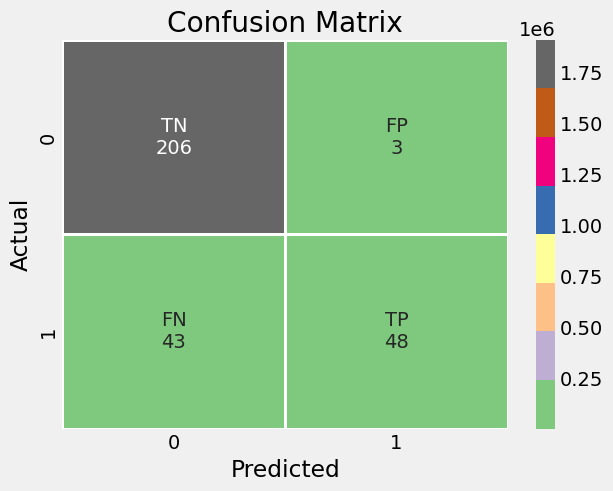

In [26]:
from sklearn.metrics import confusion_matrix
y_pred = lr.predict(X_test_ss)
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.style.use('fivethirtyeight')
labels = np.array([
    ['TN\n206', 'FP\n3'],
    ['FN\n43', 'TP\n48']
])
sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap= 'Accent',
    linewidths=1,
    linecolor='white'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test_ss)

print('\nClassification Report: ')
print(classification_report(y_test, y_pred))


Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.84      0.19      0.32      2435

    accuracy                           1.00   1908786
   macro avg       0.92      0.60      0.66   1908786
weighted avg       1.00      1.00      1.00   1908786



* The logic regression achieves a strong overal accuracy of 84%
* When the model predicts non-fraud and fraud activities, it is correct 83% and 94% of the time, respectfully
* However, the main weakness is the recall for faud. It only catches 53% of actual fraudulent transactions and 99% of non-faud transactions.
* It has an excellent and moderate performance of fraud of non fraud f1 scores.
* The metrics indicate the the model tends to miss a portion of faudulent transactions. The trade-off reflects conservative prediction behavior and highlights class imbalance effects.

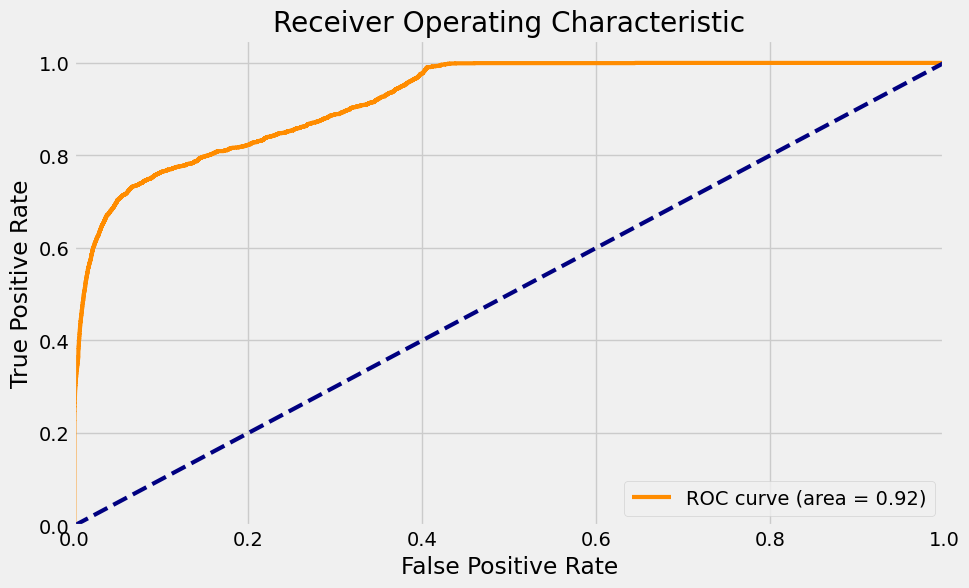

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc

y_pred = lr.predict(X_test_ss)
y_probs =lr.predict_proba(X_test_ss)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.style.use('fivethirtyeight')
plt.plot(fpr, tpr, color='darkorange', lw=3, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [29]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]258369
}).sort_values(by='Coefficient')

plt.figure(figsize=(8,5))
plt.style.use('fivethirtyeight')
sns.barplot(data=coef_df, x='Coefficient', y='Feature', color='green')
plt.title('Logistic Regression Coefficients')
plt.axvline(0, color='black')
plt.show()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (4148004271.py, line 3)

# Logistic Model Summary

We have evaluted two logistic regressio models:
1. The first model includes mismatch balance features  (`origBalanceMismatch`, `destBalanceMismatch`)
2. The second model uses only transactional and behavioral features (`amount`, `accountDiff`, `isPayment`, `isMovement`)


#### While the model with balance mismatch features achieved near-perfect performance on this synthetic dataset, it may be overly optimistic due to the deterministic nature of those features in simulated data.

#### After removing the mismatch features, the model still achieved strong performance (ROC-AUC ≈ 0.90) with improved robustness and interpretability. This suggests that behavioral and monetary signals alone provide meaningful fraud detection capability.

#### For the final step, I will use the simpler feature set to better reflect real-world situation of limited known features.


# Using the Model on New Transactions
### We will evaluate 4 transactions using the above preprocessing pipeline as the training data. The model will output both a predicted class and an associated probability, allowing for nuanced decision-making rather than relying on a binary label.

In [ ]:
# New transaction data
transaction1 = np.array([123456.78, 0.0, 1.0, 54670.1])
transaction2 = np.array([98765.43, 1.0, 0.0, 8524.75])
transaction3 = np.array([543678.31, 1.0, 0.0, 510025.5])
transaction4 = np.array([734104.8, 0.0, 1.0, 14975.6])

# Combine new transactions into a single array
my_transactions = np.stack((transaction1, transaction2, transaction3, transaction4))

# Turn this NumPy array into a DataFrame, to avoid the 'feature names are missing' warning from sklearn
my_transactions_df = pd.DataFrame(my_transactions,
                               columns= ['amount', 'isPayment', 'isMovement',
                                         'accountDiff'])

# Normalize the new transactions
my_transactions_ss_df = ss.transform(my_transactions_df)

# Predict fraud on the new transactions
preds= lr.predict(my_transactions_ss_df)

# Show probabilities on the new transactions
probs = lr.predict_proba(my_transactions_ss_df)

for i in range(len(preds)):
  print(f'Transaction {i+1}:')
  print(f"Predicted class: {'Fraud' if preds[i] == 1 else 'Not Fraud'}")
  print(f'Probability of NOT fraud: {probs[i][0]: 0.2%}')
  print(f'Probability of fraud: {probs[i][1]: 0.2%}')
  print('-' * 40)

# The Results

The outputs show that the model predicts low fraud probabilities for Transactions 2 and 3 while flagging Transaction 4 as high-risk with a fraud probability above 70%. Transaction 1 falls closer to the decision boundary, indicating how probability scores can help review borderline cases instead of making rigid positive/negative determinations.

In [ ]:
# display(transactions.head(20))
# print(transactions.info())